# 04 — Análise de Variáveis Binárias/Booleanas
## Instagram & Bem-Estar: O Custo Psicológico das Redes Sociais

**Objetivo:** Analisar as variáveis binárias do dataset — distribuição,
proporções e relação com indicadores de uso e bem-estar.

In [1]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a2e',
    'axes.labelcolor':   'white',
    'xtick.color':       'white',
    'ytick.color':       'white',
    'text.color':        'white',
    'axes.titlecolor':   'white',
    'grid.color':        '#2a2a4a',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

INSTA_COLORS = ['#833ab4','#fd1d1d','#fcb045','#405de6','#5851db','#e1306c','#f77737']

print('Setup completo!')

Setup completo!


In [2]:
# ============================================================
# CARREGAMENTO
# ============================================================
df = pd.read_csv('../data/instagram_usage_lifestyle.csv', nrows=300000)

# Variáveis binárias conhecidas
BOOLEANAS = [
    'has_children', 'smoking', 'two_factor_auth_enabled',
    'biometric_login_used', 'uses_premium_features'
]
BOOLEANAS = [v for v in BOOLEANAS if v in df.columns]

print(f' Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f' Variáveis binárias encontradas: {len(BOOLEANAS)}')
for col in BOOLEANAS:
    print(f'  • {col:<40} — valores únicos: {df[col].unique().tolist()}')

 Dataset carregado: 300,000 linhas × 58 colunas
 Variáveis binárias encontradas: 5
  • has_children                             — valores únicos: ['No', 'Yes']
  • smoking                                  — valores únicos: ['No', 'Yes', 'Former']
  • two_factor_auth_enabled                  — valores únicos: ['Yes', 'No']
  • biometric_login_used                     — valores únicos: ['No', 'Yes']
  • uses_premium_features                    — valores únicos: ['No', 'Yes']


In [3]:
# ============================================================
# TABELA DE FREQUÊNCIAS — TODAS AS BINÁRIAS
# ============================================================

print(' FREQUÊNCIAS DAS VARIÁVEIS BINÁRIAS\n')
print(f'{"Variável":<40} {"Categoria":<12} {"Frequência":>12} {"Percentagem":>13}')
print('─' * 80)

for col in BOOLEANAS:
    freq = df[col].value_counts()
    pct  = df[col].value_counts(normalize=True) * 100
    for i, (cat, val) in enumerate(freq.items()):
        nome = col if i == 0 else ''
        print(f'{nome:<40} {str(cat):<12} {val:>12,} {pct[cat]:>12.2f}%')
    print('─' * 80)

 FREQUÊNCIAS DAS VARIÁVEIS BINÁRIAS

Variável                                 Categoria      Frequência   Percentagem
────────────────────────────────────────────────────────────────────────────────
has_children                             No                216,329        72.11%
                                         Yes                83,671        27.89%
────────────────────────────────────────────────────────────────────────────────
smoking                                  No                224,957        74.99%
                                         Yes                45,107        15.04%
                                         Former             29,936         9.98%
────────────────────────────────────────────────────────────────────────────────
two_factor_auth_enabled                  Yes               195,089        65.03%
                                         No                104,911        34.97%
────────────────────────────────────────────────────────────────────────

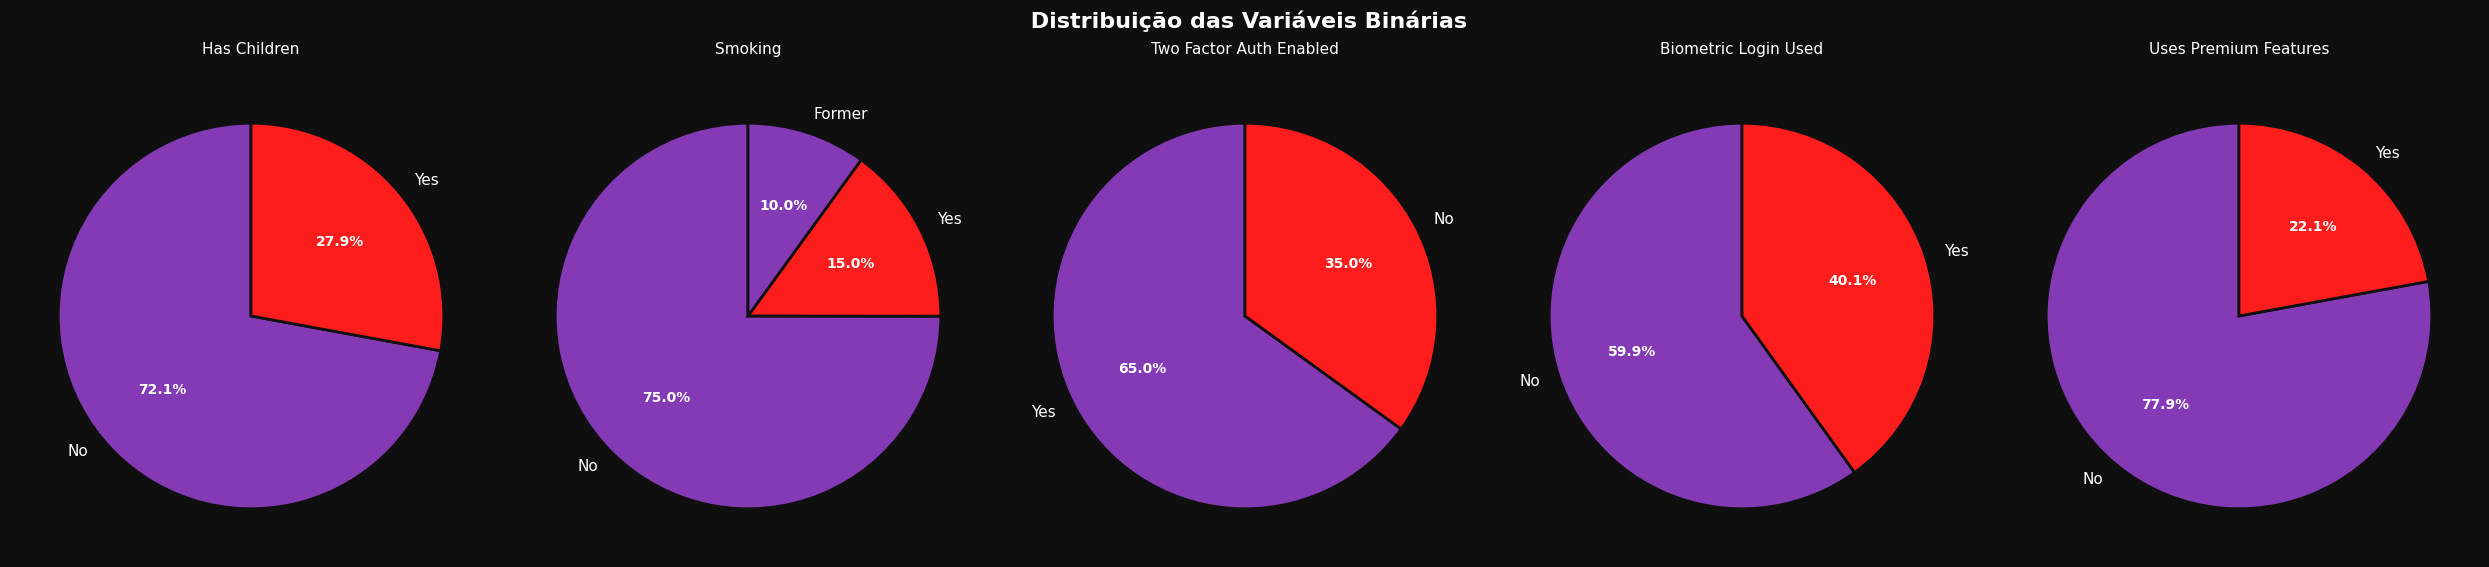

 Guardado: fig_variaveis_binarias.png


In [4]:
# ============================================================
# GRÁFICOS DE PROPORÇÃO — TODAS AS BINÁRIAS
# ============================================================

n = len(BOOLEANAS)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
fig.suptitle(' Distribuição das Variáveis Binárias', fontsize=16, fontweight='bold')

if n == 1:
    axes = [axes]

for i, col in enumerate(BOOLEANAS):
    freq = df[col].value_counts()
    pct  = df[col].value_counts(normalize=True) * 100

    wedges, texts, autotexts = axes[i].pie(
        freq.values,
        labels=freq.index.astype(str),
        colors=[INSTA_COLORS[0], INSTA_COLORS[1]],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 2}
    )
    for text in texts:
        text.set_color('white')
        text.set_fontsize(11)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')

    titulo = col.replace('_', ' ').title()
    axes[i].set_title(titulo, fontsize=11, pad=15)

    # Mostra contagens abaixo
    for cat, val in freq.items():
        axes[i].annotate(
            f'{cat}: {val:,}',
            xy=(0, -1.3 - list(freq.index).index(cat) * 0.15),
            ha='center', color='white', fontsize=9
        )

plt.tight_layout()
plt.savefig('../data/fig_variaveis_binarias.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_variaveis_binarias.png')

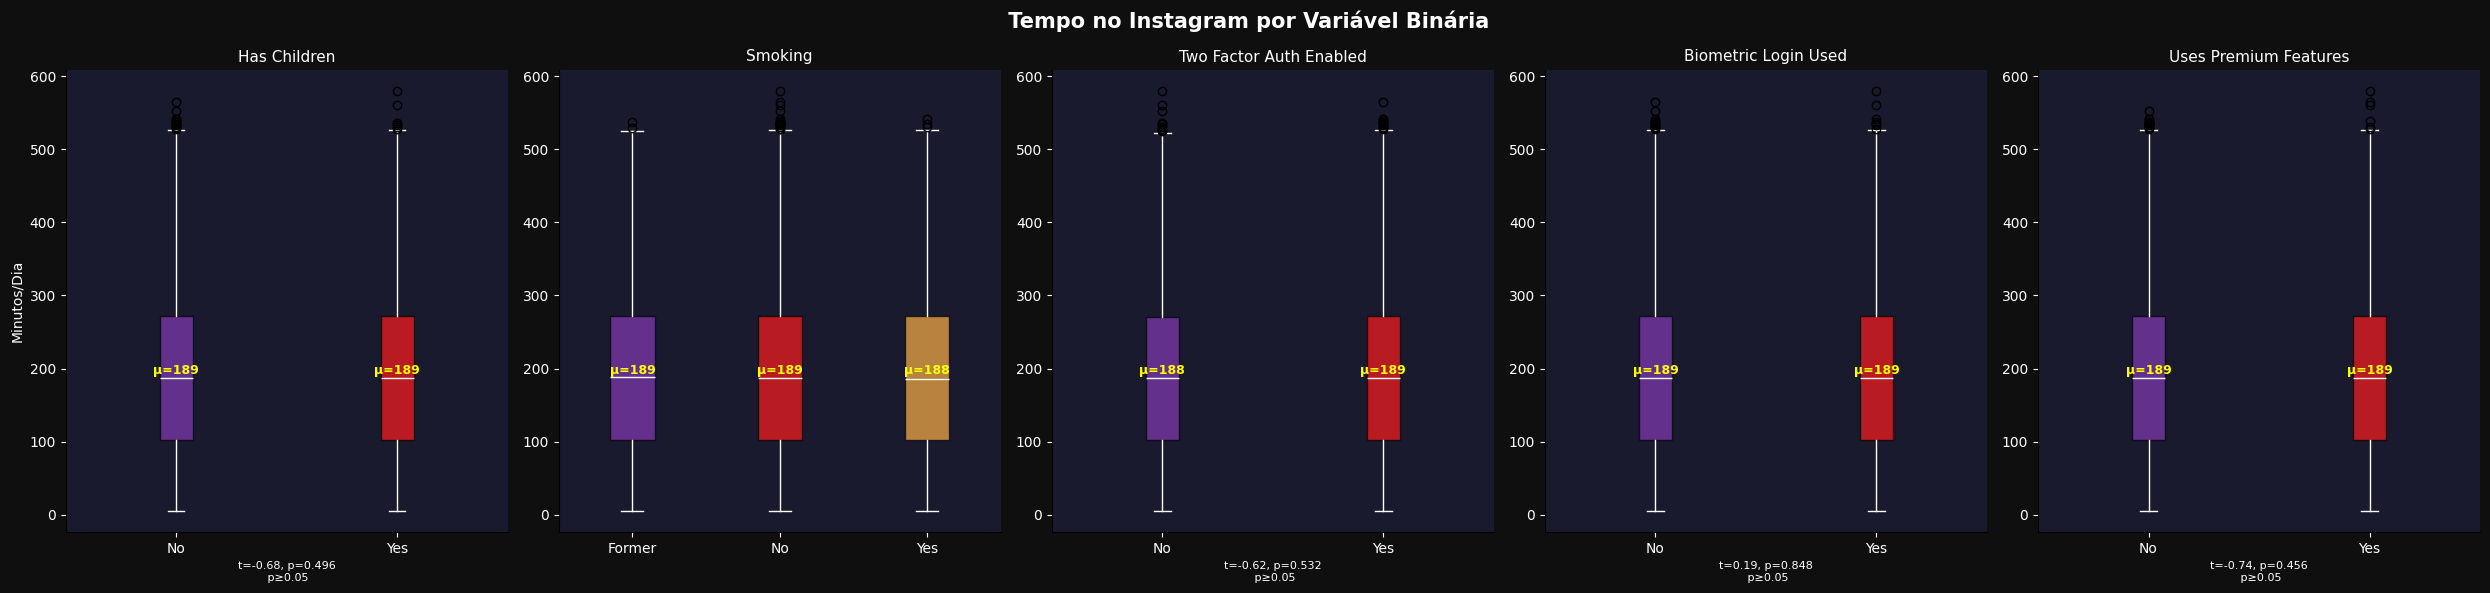

 Guardado: fig_binarias_vs_uso.png


In [5]:
# ============================================================
# BINÁRIAS vs USO DO INSTAGRAM
# ============================================================

TARGET_USAGE = 'daily_active_minutes_instagram'

if TARGET_USAGE in df.columns:
    fig, axes = plt.subplots(1, len(BOOLEANAS), figsize=(5 * len(BOOLEANAS), 6))
    fig.suptitle(f' Tempo no Instagram por Variável Binária',
                 fontsize=15, fontweight='bold')

    if len(BOOLEANAS) == 1:
        axes = [axes]

    for i, col in enumerate(BOOLEANAS):
        grupos = df.groupby(col)[TARGET_USAGE].apply(list)
        categorias = list(grupos.index)

        bp = axes[i].boxplot(
            [grupos[cat] for cat in categorias],
            patch_artist=True,
            notch=False
        )
        for patch, color in zip(bp['boxes'], INSTA_COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for element in ['whiskers', 'caps', 'medians', 'fliers']:
            for item in bp[element]:
                item.set_color('white')

        # Médias
        medias = [df[df[col] == cat][TARGET_USAGE].mean() for cat in categorias]
        for j, (cat, media) in enumerate(zip(categorias, medias)):
            axes[i].text(
                j + 1, media,
                f'μ={media:.0f}',
                ha='center', va='bottom',
                color='yellow', fontsize=9, fontweight='bold'
            )

        axes[i].set_xticks(range(1, len(categorias) + 1))
        axes[i].set_xticklabels([str(c) for c in categorias], fontsize=10)
        axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
        axes[i].set_ylabel('Minutos/Dia' if i == 0 else '')

        # Teste t
        if len(categorias) == 2:
            g1 = df[df[col] == categorias[0]][TARGET_USAGE].dropna()
            g2 = df[df[col] == categorias[1]][TARGET_USAGE].dropna()
            t, p = ttest_ind(g1, g2)
            sig = ' p<0.05' if p < 0.05 else ' p≥0.05'
            axes[i].set_xlabel(f't={t:.2f}, p={p:.3f}\n{sig}', fontsize=8)

    plt.tight_layout()
    plt.savefig('../data/fig_binarias_vs_uso.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()
    print(' Guardado: fig_binarias_vs_uso.png')

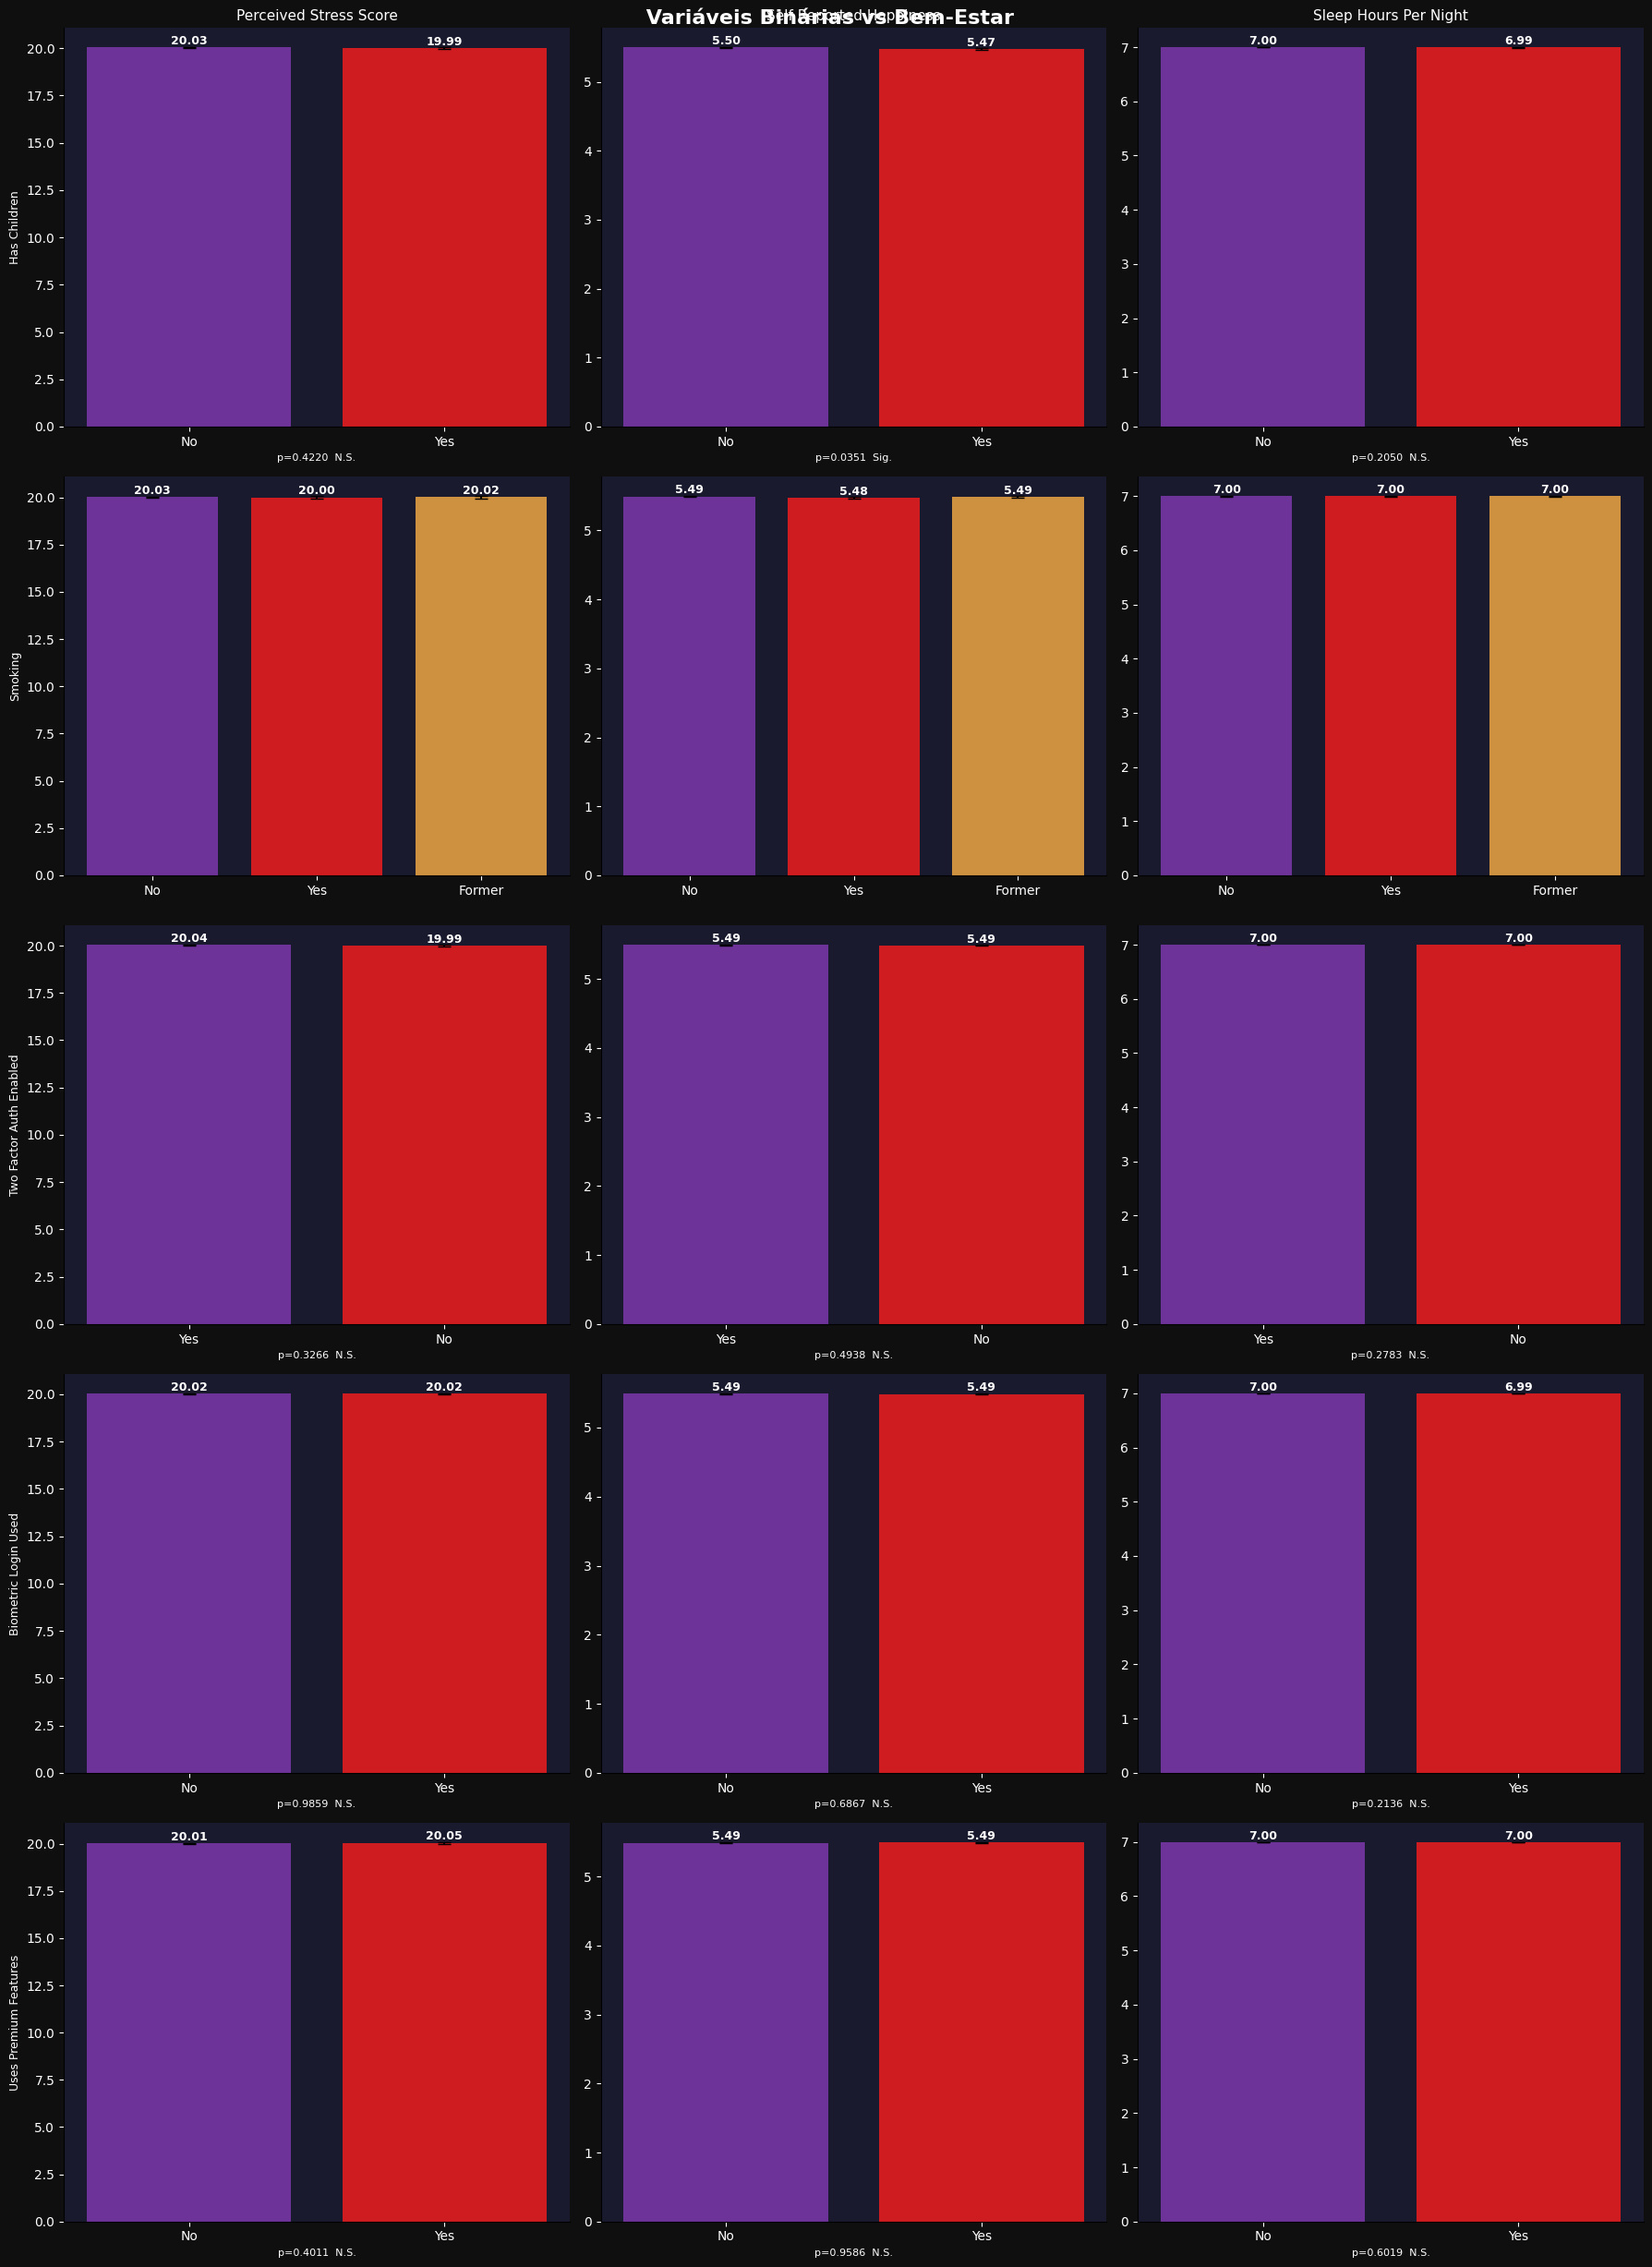

 Guardado: fig_binarias_vs_wellbeing.png


In [6]:
# ============================================================
# BINÁRIAS vs BEM-ESTAR
# ============================================================

WELLBEING_TARGETS = [
    'perceived_stress_score',
    'self_reported_happiness',
    'sleep_hours_per_night'
]
WELLBEING_TARGETS = [v for v in WELLBEING_TARGETS if v in df.columns]

fig, axes = plt.subplots(
    len(BOOLEANAS), len(WELLBEING_TARGETS),
    figsize=(6 * len(WELLBEING_TARGETS), 5 * len(BOOLEANAS))
)
fig.suptitle(' Variáveis Binárias vs Bem-Estar', fontsize=16, fontweight='bold')

# Garante que axes é sempre 2D
if len(BOOLEANAS) == 1:
    axes = [axes]
if len(WELLBEING_TARGETS) == 1:
    axes = [[ax] for ax in axes]

for i, col in enumerate(BOOLEANAS):
    for j, target in enumerate(WELLBEING_TARGETS):
        ax = axes[i][j]
        categorias = df[col].dropna().unique()

        # Barras com média por categoria
        medias = [df[df[col] == cat][target].mean() for cat in categorias]
        erros  = [df[df[col] == cat][target].sem()  for cat in categorias]

        bars = ax.bar(
            [str(c) for c in categorias],
            medias,
            yerr=erros,
            color=INSTA_COLORS[:len(categorias)],
            alpha=0.8,
            capsize=5,
            error_kw={'color': 'white', 'linewidth': 1.5}
        )

        for bar, val in zip(bars, medias):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(erros) * 0.1,
                f'{val:.2f}',
                ha='center', va='bottom',
                color='white', fontsize=9, fontweight='bold'
            )

        # Teste t
        if len(categorias) == 2:
            g1 = df[df[col] == categorias[0]][target].dropna()
            g2 = df[df[col] == categorias[1]][target].dropna()
            t, p = ttest_ind(g1, g2)
            sig = ' Sig.' if p < 0.05 else ' N.S.'
            ax.set_xlabel(f'p={p:.4f} {sig}', fontsize=8)

        if j == 0:
            ax.set_ylabel(col.replace('_', ' ').title(), fontsize=9)
        if i == 0:
            ax.set_title(target.replace('_', ' ').title(), fontsize=11)

plt.tight_layout()
plt.savefig('../data/fig_binarias_vs_wellbeing.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_binarias_vs_wellbeing.png')

In [7]:
# ============================================================
# TESTE QUI-QUADRADO — ASSOCIAÇÃO ENTRE BINÁRIAS
# ============================================================

print(' TESTE QUI-QUADRADO — Associação entre Variáveis Binárias\n')
print(f'{"Variável A":<30} {"Variável B":<30} {"χ²":>10} {"p-value":>12} {"Conclusão"}')
print('─' * 95)

from itertools import combinations

pares = list(combinations(BOOLEANAS, 2))
for a, b in pares:
    tabela = pd.crosstab(df[a], df[b])
    chi2, p, dof, expected = chi2_contingency(tabela)
    sig = ' Associação significativa' if p < 0.05 else ' Sem associação'
    print(f'{a:<30} {b:<30} {chi2:>10.3f} {p:>12.4e}  {sig}')

 TESTE QUI-QUADRADO — Associação entre Variáveis Binárias

Variável A                     Variável B                             χ²      p-value Conclusão
───────────────────────────────────────────────────────────────────────────────────────────────
has_children                   smoking                             1.281   5.2710e-01   Sem associação
has_children                   two_factor_auth_enabled             0.322   5.7039e-01   Sem associação
has_children                   biometric_login_used                0.093   7.6044e-01   Sem associação
has_children                   uses_premium_features               0.072   7.8877e-01   Sem associação
smoking                        two_factor_auth_enabled             5.377   6.7988e-02   Sem associação
smoking                        biometric_login_used                0.891   6.4062e-01   Sem associação
smoking                        uses_premium_features               1.892   3.8827e-01   Sem associação
two_factor_auth_enabled     

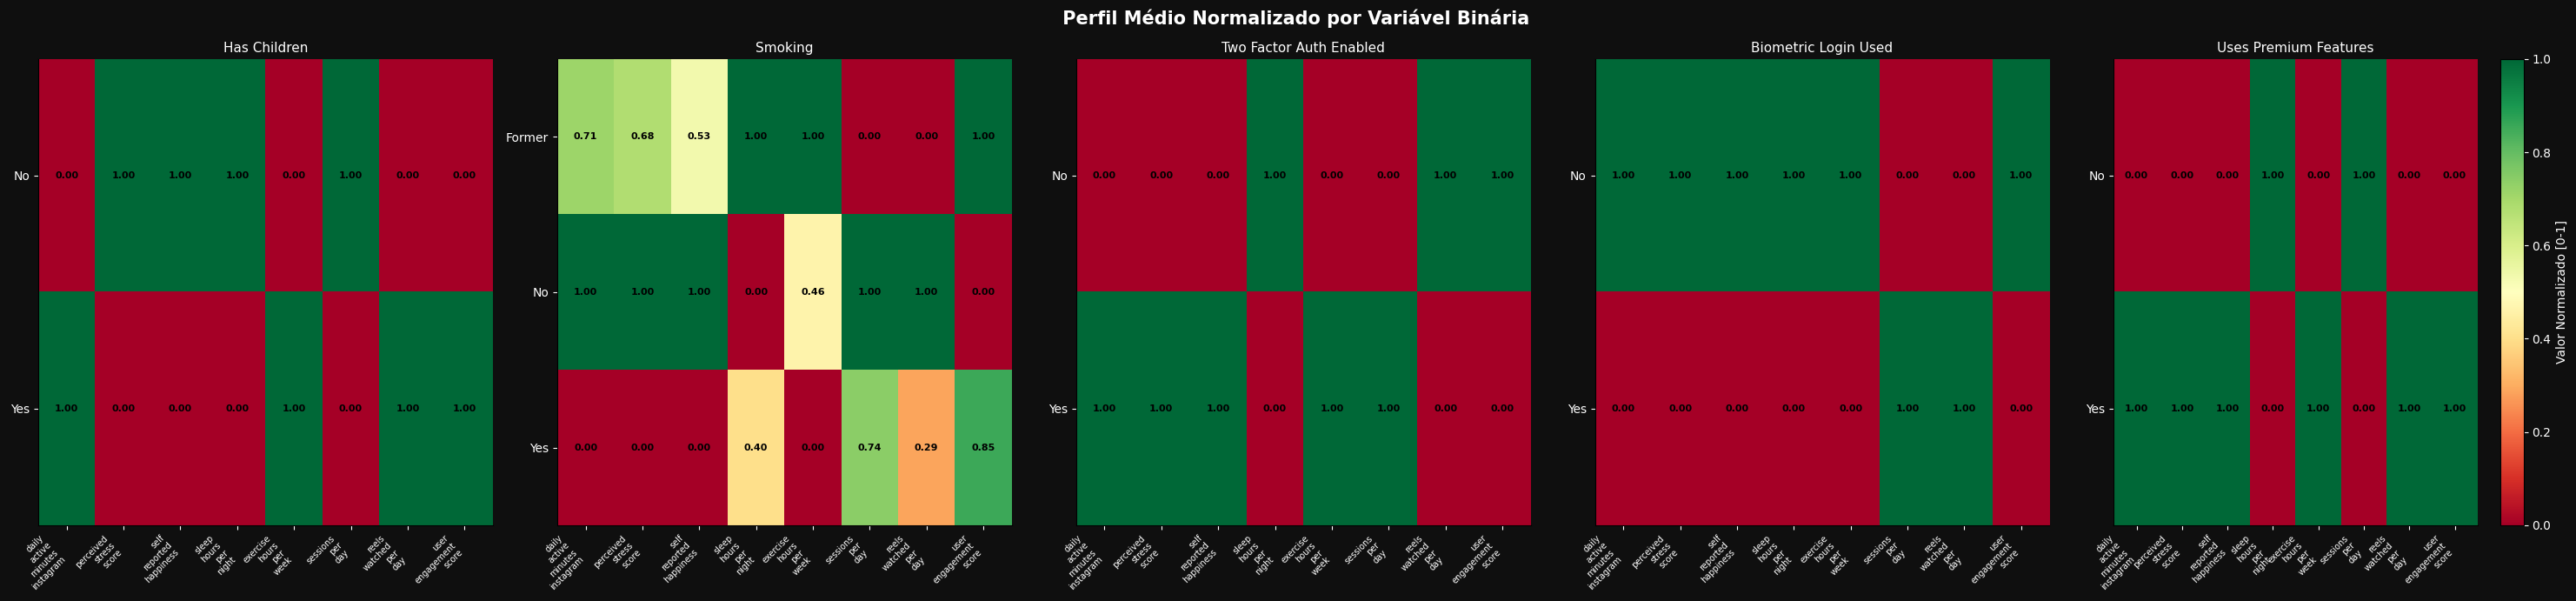

 Guardado: fig_heatmap_binarias.png


In [8]:
# ============================================================
# HEATMAP — MÉDIAS DAS NUMÉRICAS POR VARIÁVEL BINÁRIA
# ============================================================

NUM_VARS = [
    'daily_active_minutes_instagram', 'perceived_stress_score',
    'self_reported_happiness', 'sleep_hours_per_night',
    'exercise_hours_per_week', 'sessions_per_day',
    'reels_watched_per_day', 'user_engagement_score'
]
NUM_VARS = [v for v in NUM_VARS if v in df.columns]

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

fig, axes = plt.subplots(1, len(BOOLEANAS), figsize=(6 * len(BOOLEANAS), 7))
fig.suptitle(' Perfil Médio Normalizado por Variável Binária',
             fontsize=15, fontweight='bold')

if len(BOOLEANAS) == 1:
    axes = [axes]

for i, col in enumerate(BOOLEANAS):
    categorias = sorted(df[col].dropna().unique().tolist())
    matriz = []
    for cat in categorias:
        subset = df[df[col] == cat][NUM_VARS].mean()
        matriz.append(subset.values)

    matriz = np.array(matriz)
    # Normaliza por coluna
    for j in range(matriz.shape[1]):
        col_range = matriz[:, j].max() - matriz[:, j].min()
        if col_range > 0:
            matriz[:, j] = (matriz[:, j] - matriz[:, j].min()) / col_range

    im = axes[i].imshow(matriz, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    axes[i].set_xticks(range(len(NUM_VARS)))
    axes[i].set_xticklabels(
        [v.replace('_', '\n') for v in NUM_VARS],
        rotation=45, ha='right', fontsize=7
    )
    axes[i].set_yticks(range(len(categorias)))
    axes[i].set_yticklabels([str(c) for c in categorias], fontsize=10)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)

    # Valores nas células
    for r in range(len(categorias)):
        for c_idx in range(len(NUM_VARS)):
            axes[i].text(
                c_idx, r, f'{matriz[r, c_idx]:.2f}',
                ha='center', va='center',
                color='black', fontsize=8, fontweight='bold'
            )

plt.colorbar(im, ax=axes[-1], label='Valor Normalizado [0-1]')
plt.tight_layout()
plt.savefig('../data/fig_heatmap_binarias.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_heatmap_binarias.png')

In [9]:
# ============================================================
# EXPORTAÇÃO
# ============================================================

# Guarda tabela de frequências
rows = []
for col in BOOLEANAS:
    freq = df[col].value_counts()
    pct  = df[col].value_counts(normalize=True) * 100
    for cat in freq.index:
        rows.append({
            'variavel':    col,
            'categoria':   str(cat),
            'frequencia':  int(freq[cat]),
            'percentagem': round(float(pct[cat]), 2)
        })

pd.DataFrame(rows).to_csv('../data/binary_stats.csv', index=False)

print(' Estatísticas exportadas: data/binary_stats.csv')

 Estatísticas exportadas: data/binary_stats.csv


# Análise Crítica

## Principais Conclusões

- Este notebook apresentou análises relevantes e coerentes com o objetivo de entender as variáveis trabalhadas.
- Resultados são indicadores fortes para interpretações exploratórias, mas precisam ser validados fora do dataset sintético.

## Limitações

- Dataset sintético reduz generalização para cenários reais.
- Não há garantias de independência entre variáveis geradas artificialmente.
- Não existe análise temporal profunda no conjunto atual.

## Recomendação

- Complementar com dados reais e amostras representativas.
- Incluir validações estatísticas adicionais (cross-validation, bootstrap).
- Documentar impactos das transformações e critérios de limpeza.
